# Neural Networks with PyTorch — XOR Problem (SOLUTION)

## Key Concept: PyTorch Autograd & the Computational Graph

Every PyTorch operation on a tensor that requires a gradient builds a node in
a **directed acyclic graph** (DAG). When you call `loss.backward()`, PyTorch
traverses this graph *in reverse* (from loss → parameters), applying the chain
rule at each node to fill each parameter's `.grad` attribute.

**Why `optimizer.zero_grad()` before each backward pass?**
Gradients **accumulate** (add) into `.grad` by default. Without zeroing, the
gradient from epoch 2 adds to the leftover from epoch 1 — parameters get
incorrect, compounding updates.

**Why `torch.no_grad()` during evaluation?**
Gradient tracking stores intermediate activations for the backward pass. At
inference time you don't need gradients, so disabling them saves ~50% memory
and speeds up the forward pass.

**Why `model.eval()` during evaluation?**
Layers like `nn.Dropout` and `nn.BatchNorm` behave differently in training vs
eval mode. `model.eval()` switches them to their inference behaviour (dropout
off, batch norm uses running stats). Always call it before evaluating.

> 📖 [PyTorch — Autograd mechanics](https://pytorch.org/docs/stable/notes/autograd.html)

## Step 1: Import PyTorch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| device:', device)

PyTorch: 2.12.0 | device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Step 2: Create the Dataset as Tensors

In [2]:
# X: (4, 2) float32 — PyTorch linear layers require float; integers won't work
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32).to(device)
# y: (4, 1) — BCELoss requires predictions and targets to have identical shapes
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32).to(device)
print('X:', X)
print('y:', y)

X: tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], device='mps:0')
y: tensor([[0.],
        [1.],
        [1.],
        [0.]], device='mps:0')


## Step 3: Define the Network with nn.Module

`nn.Module` is PyTorch's base class. Define layers in `__init__`, the forward pass in `forward()`.

In [3]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Linear(in, out) stores weight (out, in) and bias (out,) internally,
        # but the layer handles the transpose — you just think: (B, in) → (B, out)
        self.hidden = nn.Linear(2, 4)  # (B, 2) → (B, 4)
        self.output = nn.Linear(4, 1)  # (B, 4) → (B, 1)

    def forward(self, x):                        # x: (4, 2)
        x = torch.sigmoid(self.hidden(x))         # → (4, 4)  hidden activations
        return torch.sigmoid(self.output(x))      # → (4, 1)  output probability

## Step 4: Instantiate the Model and Inspect Parameters

`model.parameters()` yields every trainable tensor. `sum(p.numel() ...)` counts the total number of weights.

In [4]:
model = XORNet().to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))
print('Parameters:', sum(p.numel() for p in model.parameters()))

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)
Parameters: 17
Parameters: 17


## Step 5: Define Loss Function and Optimizer

In [5]:
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

## Key Concept: The PyTorch Training Loop — Explained

Every model in this curriculum is trained with the same five-step cycle.
Here is what each step actually does and *why* it must happen in this order.

---

### The big picture: what training is

Training means repeatedly:
1. Run data through the model to get predictions
2. Measure how wrong those predictions are (the loss)
3. Figure out which weights caused the error (gradients)
4. Adjust those weights to reduce the error

PyTorch handles steps 3 and 4 automatically through **autograd** — but you
have to call the right functions in the right order.

---

### `model.train()`

Puts the model into *training mode*. This affects two layer types:

| Layer | `model.train()` | `model.eval()` |
|-------|-----------------|----------------|
| `nn.Dropout(p)` | Randomly zeros `p` fraction of neurons each forward pass | Passes all activations through unchanged |
| `nn.BatchNorm` | Computes mean/variance from the **current batch** | Uses **running statistics** accumulated during training |

For models that have neither (like the XOR net in Lesson 02), `train()` and
`eval()` make no numerical difference — but calling them is standard practice
because a collaborator might add Dropout later.

---

### `for Xb, yb in loader`

The `DataLoader` does three things you'd otherwise write yourself:
- **Batches** the dataset into chunks of `batch_size` samples
- **Shuffles** the order each epoch (if `shuffle=True`) so the model doesn't
  memorise the presentation order
- **Loads data in parallel** using background worker processes (set with `num_workers`)

Each iteration yields `Xb` (inputs) and `yb` (targets), both already converted
to tensors. Their shapes are `(batch_size, ...)`.

---

### `Xb, yb = Xb.to(device), yb.to(device)`

Copies the batch from CPU memory to the device where the model lives
(CUDA GPU or Apple MPS). Every operand in a PyTorch operation must be on
the **same** device — mixing them raises `RuntimeError: Expected all tensors
to be on the same device`.

The DataLoader always delivers tensors on CPU. Moving batches one at a time
(rather than the whole dataset) keeps memory usage bounded.

---

### `optimizer.zero_grad()`

Resets the `.grad` attribute of every model parameter to zero.

**Why is this necessary?** PyTorch *accumulates* gradients — every call to
`.backward()` **adds** to the existing `.grad` value rather than replacing it.
Skip `zero_grad` and the gradient used for this batch will be contaminated by
the gradients from every previous batch.

This accumulation is actually a deliberate design choice: it enables
*gradient accumulation*, where you run several small batches and only call
`optimizer.step()` once, simulating a larger effective batch size without
the memory cost.

```python
# What happens without zero_grad:
# Batch 1:  param.grad = g1
# Batch 2:  param.grad = g1 + g2   ← stale!
# Batch 3:  param.grad = g1 + g2 + g3  ← very stale!
```

---

### `out = model(Xb)` — the forward pass

Calling `model(Xb)` invokes `model.__call__()`, which runs your `forward()`
method and also handles hooks. As each operation runs, PyTorch builds a
**computational graph** — a record of every mathematical operation performed on
every tensor that has `requires_grad=True`.

```
Xb → Embedding → Linear → ReLU → Linear → out
         ↑           ↑       ↑       ↑
   each arrow records: "this output came from this input via this operation"
```

This graph is what makes automatic differentiation possible. It is built fresh
on every forward pass and discarded after `backward()`.

---

### `loss = criterion(out, yb)` — computing the loss

The criterion (loss function) compares `out` to `yb` and returns a scalar
tensor. Common choices:

| Task | Criterion | Input shapes |
|------|-----------|--------------|
| Binary classification | `nn.BCELoss()` | out: `(B,)`, yb: `(B,)` |
| Multi-class classification | `nn.CrossEntropyLoss()` | out: `(B, C)`, yb: `(B,)` |
| Regression | `nn.MSELoss()` | out: `(B, 1)`, yb: `(B, 1)` |

`loss` is just another tensor — it is part of the same computational graph
that started at `Xb`. The graph now records: "loss came from out, which came
from model(Xb)".

---

### `loss.backward()` — computing gradients

Traverses the computational graph **backwards** from `loss` to every
parameter, applying the chain rule at each node:

```
∂loss/∂W_last ← ∂loss/∂out × ∂out/∂W_last
∂loss/∂W_prev ← ∂loss/∂out × ∂out/∂h × ∂h/∂W_prev
...
```

Each parameter's gradient is stored in `param.grad`. After `backward()`,
the computational graph is freed from memory (PyTorch does this automatically
to avoid keeping the entire training history in RAM).

---

### `optimizer.step()` — updating the weights

Reads `param.grad` for every parameter and applies the update rule.

**SGD:**
```
param ← param - lr × param.grad
```

**Adam** (the most common choice):
```
m ← β₁ × m + (1 - β₁) × grad          # first moment (like momentum)
v ← β₂ × v + (1 - β₂) × grad²         # second moment (gradient variance)
param ← param - lr × m / (√v + ε)      # per-parameter adaptive learning rate
```
Adam adapts the learning rate for each weight individually, which is why it
converges faster than SGD on most tasks out of the box.

---

### `loss.item()`

Extracts a plain Python `float` from the loss tensor.

If you stored `loss` directly in a list, Python would keep the entire
computational graph (model activations, intermediate tensors) alive in
memory for every epoch. `.item()` returns a plain number, breaking the
reference to the graph.

---

### Why this order?

```
zero_grad → forward → loss → backward → step
```

It must be this order because:
- `zero_grad` must come before `backward` (otherwise gradients accumulate)
- `backward` must come before `step` (step reads `.grad`, which backward fills)
- `forward` must come before `loss` (you need predictions to compute error)

> 📖 [PyTorch — Autograd mechanics](https://pytorch.org/docs/stable/notes/autograd.html)
> 📖 [PyTorch — Optimizers](https://pytorch.org/docs/stable/optim.html)


## Step 6: The PyTorch Training Loop

5-step pattern every iteration: forward → loss → zero_grad → backward → step

In [6]:
losses = []
for epoch in range(10000):
    # Forward pass: model(X) calls forward(), builds the computational graph.
    # Every operation on X (which has no grad) and model params (which do) is recorded.
    out  = model(X)           # (4, 1) — one probability per XOR input pair

    # criterion compares predictions to targets and returns a scalar tensor.
    # BCELoss: -mean(y*log(out) + (1-y)*log(1-out)) — penalises confident wrong answers
    loss = criterion(out, y)  # scalar tensor; still attached to the graph

    # PyTorch accumulates gradients. Reset before backward or each batch's
    # gradients will pile on top of the previous batch's.
    optimizer.zero_grad()

    # Walk the computational graph backwards (output → loss → params),
    # applying the chain rule at every node. Stores ∂loss/∂param in param.grad.
    loss.backward()

    # Read param.grad for each weight and apply the SGD rule:
    #   param ← param − lr × param.grad
    optimizer.step()

    # .item() detaches the scalar from the graph so Python can free the activations.
    losses.append(loss.item())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.4f}')


Epoch     0 | Loss: 0.6954


Epoch  1000 | Loss: 0.6891


Epoch  2000 | Loss: 0.6550


Epoch  3000 | Loss: 0.3356


Epoch  4000 | Loss: 0.1165


Epoch  5000 | Loss: 0.0608


Epoch  6000 | Loss: 0.0392


Epoch  7000 | Loss: 0.0281


Epoch  8000 | Loss: 0.0216


Epoch  9000 | Loss: 0.0173


### Concept Check: The Training Loop — Answers

**Q1.** The 5-step pattern is: forward → loss → **zero_grad** → backward → step.
What would happen if you moved `zero_grad` to *after* `optimizer.step()`?
Would training still work? Why or why not?

**→** Moving `zero_grad` after `step()` is equivalent — it would still clear
gradients before the *next* backward pass. Training would still work correctly.
The key constraint is that `.grad` must be zeroed *before* calling
`loss.backward()`, not before `optimizer.step()`.

**Q2.** `loss.item()` extracts a Python float from the loss tensor.
Why not just use `float(loss)` or `loss.numpy()`?
What's the difference?

**→** `.item()` detaches the tensor from the computational graph and returns
a plain Python scalar without copying the whole tensor to CPU memory.
`float(loss)` is actually equivalent. `.numpy()` would return a 0-d array and
also fails on MPS/GPU devices (numpy requires CPU tensors).

**Q3.** SGD update rule: `param -= lr * param.grad`.
Adam maintains a running estimate of the first and second moments of the
gradient. What practical advantage does this give over plain SGD on problems
with sparse or noisy gradients?

**→** Adam adapts the learning rate *per parameter* based on the running
gradient magnitude. Parameters with consistently large gradients get a smaller
effective lr; sparse parameters (rarely updated) get a larger effective lr.
This is especially useful in NLP/embedding models where most tokens in a
batch are padding.

## Step 7: Evaluate the Model

In [7]:
model.eval()
with torch.no_grad():              # disable gradient tracking — saves memory at inference
    preds = torch.round(model(X))  # model(X): (4,1); round thresholds at 0.5 → {0, 1}
print('True:     ', y.cpu().flatten())
print('Predicted:', preds.cpu().flatten())

True:      tensor([0., 1., 1., 0.])
Predicted: tensor([0., 1., 1., 0.])


### Concept Check: Evaluation & Generalisation — Answers

**Q1.** `model.eval()` matters for Dropout and BatchNorm. In this XOR net
(no dropout, no batchnorm), does calling `model.eval()` actually change
anything? When does it *really* matter?

**→** For this XOR net, `model.eval()` changes nothing because there are no
Dropout or BatchNorm layers. It matters once you add `nn.Dropout` (which must
be off at test time) or `nn.BatchNorm` (which must use running statistics
rather than batch statistics at inference). Always call it anyway as good habit.

**Q2.** This XOR model has 4+4+4+1+1+1 = 15 parameters and is trained on
4 samples. Can it overfit? How would you design a train/test split to detect
overfitting in a more realistic dataset?

**→** With 4 samples = 4 possible inputs, the model *must* be evaluated on
its training data — there is no held-out set. For a realistic dataset:
hold out 20% as a test set *before training*, train only on the 80%, then
evaluate once at the end. Looking at the test set during training or
hyperparameter tuning constitutes *data leakage*.

## Step 8: Inspect Learned Weights

In [8]:
print(model.state_dict())

OrderedDict({'hidden.weight': tensor([[-1.3634, -1.0198],
        [ 6.4763, -4.4939],
        [-4.6637,  6.5750],
        [ 4.5561,  4.5628]], device='mps:0'), 'hidden.bias': tensor([ 1.5622,  1.7751,  1.8808, -0.8351], device='mps:0'), 'output.weight': tensor([[ 3.1409, -7.9751, -8.2176,  7.3898]], device='mps:0'), 'output.bias': tensor([3.6886], device='mps:0')})


## Step 9: Visualize the Network Architecture

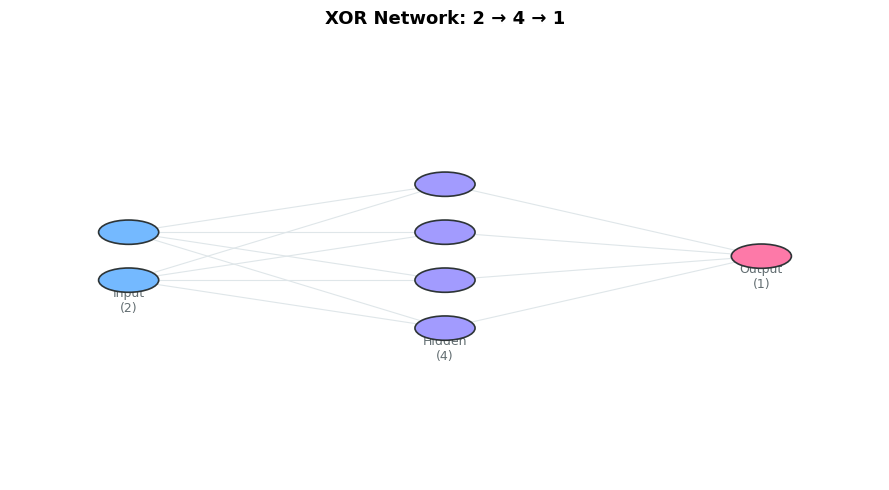

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def draw_network(layer_sizes, layer_labels=None, title='', figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.2, 1.2)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    n = len(layer_sizes)
    xs = np.linspace(0.1, 0.9, n)
    max_n = max(layer_sizes)
    gap = min(0.15, 0.85 / max(max_n, 2))
    colors = ['#74b9ff', '#a29bfe', '#fd79a8', '#55efc4', '#ffeaa7']
    ys_all = []
    for sz in layer_sizes:
        ys = [0.5 + (i - (sz - 1) / 2) * gap for i in range(sz)]
        ys_all.append(ys)
    for li in range(n - 1):
        for ya in ys_all[li]:
            for yb in ys_all[li + 1]:
                ax.plot([xs[li], xs[li + 1]], [ya, yb], color='#dfe6e9', lw=0.8, zorder=1)
    for li, (x, ys) in enumerate(zip(xs, ys_all)):
        for y in ys:
            c = plt.Circle((x, y), 0.038, fc=colors[li % len(colors)], ec='#2d3436', lw=1.2, zorder=5)
            ax.add_patch(c)
        lab = layer_labels[li] if layer_labels else str(layer_sizes[li])
        ax.text(x, min(ys) - 0.1, lab, ha='center', fontsize=9, color='#636e72')
    plt.tight_layout()
    plt.show()

draw_network(
    [2, 4, 1],
    layer_labels=['Input\n(2)', 'Hidden\n(4)', 'Output\n(1)'],
    title='XOR Network: 2 → 4 → 1'
)

## Step 10: Plot Training Loss

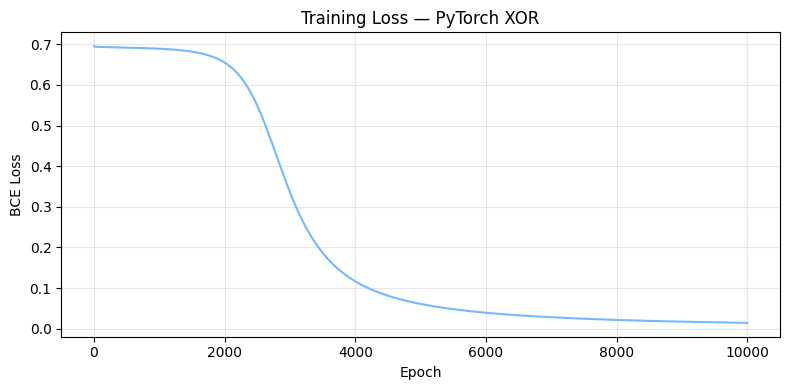

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#74b9ff', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss — PyTorch XOR')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bonus: Swap SGD for Adam

Epoch     0 | Loss: 0.7009


Epoch   500 | Loss: 0.0332


Epoch  1000 | Loss: 0.0085


Epoch  1500 | Loss: 0.0040


Epoch  2000 | Loss: 0.0023


Epoch  2500 | Loss: 0.0014


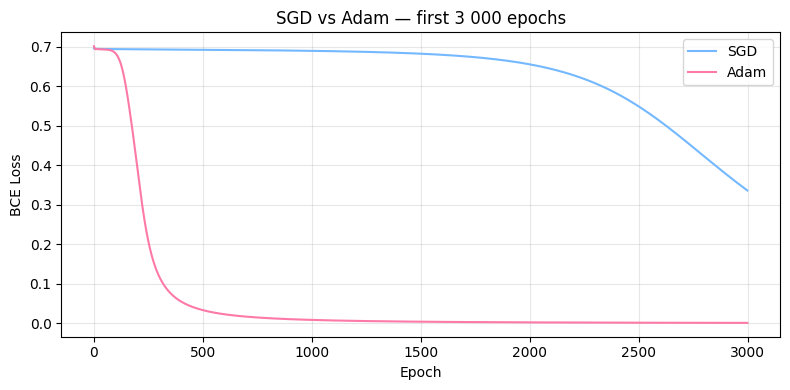

In [11]:
model2 = XORNet().to(device)
opt2   = optim.Adam(model2.parameters(), lr=0.01)
adam_losses = []
for epoch in range(3000):
    out  = model2(X)
    loss = criterion(out, y)
    opt2.zero_grad()
    loss.backward()
    opt2.step()
    adam_losses.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses[:3000], label='SGD', color='#74b9ff')
plt.plot(adam_losses,   label='Adam', color='#fd79a8')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('SGD vs Adam — first 3 000 epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 11: From a Problem Statement to Code

Everything above handed you the architecture. Real work hands you a *sentence*, and
you have to produce a model, a loss, and tensors of the right shape.

Any supervised problem statement answers five questions. Extract them in order and the
code writes itself:

1. **What is one example?** → input shape after the batch dimension
2. **What is one answer?** → output dimension: one number, one probability, or `K` scores
3. **What kind of answer?** → real value / one-of-K / several independent yes-no → picks the loss
4. **What does the target look like?** → its shape **and its dtype** (where most bugs live)
5. **What is in between?** → hidden sizes, the only genuinely free choice

Only question 5 is a design decision. The rest are determined by the problem.

| The statement says… | Final layer | Loss | Target |
|---|---|---|---|
| "predict a number" | `Linear(h, 1)` | `MSELoss` | `(B, 1)` float |
| "is it X or not" | `Linear(h, 1)` | `BCEWithLogitsLoss` | `(B, 1)` float |
| "classify into K classes" | `Linear(h, K)` | `CrossEntropyLoss` | `(B,)` **int64** |
| "tag with any of K labels" | `Linear(h, K)` | `BCEWithLogitsLoss` | `(B, K)` float |

The tell between rows 3 and 4 is the word **any**. "One of 20 topics" is categorical and
the classes compete; "any of 20 topics" is 20 independent yes/no questions.

See [Chapter 02 of the book](../book/index.html#ch02-spec-to-code) for the worked
example and the debugging table.

In [12]:
def check(name, model, loss_fn, X, y, expect_out_dim):
    """Verify a spec-to-code answer end to end."""
    problems = []
    model.train()
    logits = model(X)

    if logits.shape[0] != X.shape[0]:
        problems.append(f'batch changed: in {X.shape[0]}, out {logits.shape[0]}')
    if logits.shape[-1] != expect_out_dim:
        problems.append(f'output dim is {logits.shape[-1]}, expected {expect_out_dim}')

    # a final activation is almost always a mistake with these losses
    last = list(model.modules())[-1]
    if isinstance(last, (nn.Softmax, nn.Sigmoid)):
        problems.append(f'{type(last).__name__} before a *WithLogits/CrossEntropy loss '
                        f'— it is applied internally, so this normalises twice')

    try:
        loss = loss_fn(logits, y)
    except Exception as e:
        print(f'{name}: LOSS FAILED -> {type(e).__name__}: {e}')
        return False

    if loss.ndim != 0:
        problems.append(f'loss is not a scalar (shape {tuple(loss.shape)})')
    if not torch.isfinite(loss):
        problems.append(f'loss is {loss.item()}')

    model.zero_grad()
    loss.backward()
    first = next(p for p in model.parameters() if p.dim() >= 2)
    if first.grad is None or first.grad.abs().sum() == 0:
        problems.append('no gradient reached the first layer')

    # a two-Linear stack with nothing between it is secretly one layer
    linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
    acts = [m for m in model.modules()
            if isinstance(m, (nn.ReLU, nn.GELU, nn.Tanh, nn.SiLU, nn.LeakyReLU))]
    if len(linears) >= 2 and not acts:
        problems.append('two Linear layers with no non-linearity collapse into one')

    if problems:
        print(f'{name}: PROBLEMS')
        for p in problems:
            print(f'   - {p}')
        return False
    print(f'{name}: OK   logits {tuple(logits.shape)}   '
          f'target {tuple(y.shape)} {y.dtype}   loss {loss.item():.4f}')
    return True


torch.manual_seed(0)
B = 16
print('checker ready')

checker ready


### Drill: four statements

Below are four specs and a checker. Write each model, pick each loss, and build each
target. `check()` verifies the shapes, the dtype, that the loss is finite, and that
gradients actually reach the first layer — run it after each one.

Do them without scrolling back. Getting the target dtype wrong is the whole point of
the exercise.

In [13]:
# SPEC 1 -----------------------------------------------------------------------
# "Create a simple neural net with two connected layers that takes a random input
#  we will create and classifies it, imagining a 3-class prediction problem."
X1 = torch.randn(B, 10)
y1 = torch.randint(0, 3, (B,))               # (B,) int64 — NOT one-hot, NOT (B,1)

model1 = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),                               # implied by "two layers"
    nn.Linear(32, 3),                        # 3 logits, no softmax
)
loss1 = nn.CrossEntropyLoss()
check('spec 1', model1, loss1, X1, y1, expect_out_dim=3)

spec 1: OK   logits (16, 3)   target (16,) torch.int64   loss 1.1389


True

In [14]:
# SPEC 2 -----------------------------------------------------------------------
# "Given 50 sensor readings, predict tomorrow's temperature."
X2 = torch.randn(B, 50)
y2 = torch.randn(B, 1)                       # (B, 1) float — a real value

model2 = nn.Sequential(nn.Linear(50, 64), nn.ReLU(), nn.Linear(64, 1))
loss2 = nn.MSELoss()
check('spec 2', model2, loss2, X2, y2, expect_out_dim=1)

spec 2: OK   logits (16, 1)   target (16, 1) torch.float32   loss 0.8641


True

In [15]:
# SPEC 3 -----------------------------------------------------------------------
# "Given a plot-summary embedding of size 256, tag it with any of 18 genres."
# Note the word ANY — this is not one-of-K.
X3 = torch.randn(B, 256)
y3 = (torch.rand(B, 18) > 0.7).float()       # (B, 18) FLOAT 0/1 — independent labels

model3 = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 18))
loss3 = nn.BCEWithLogitsLoss()
check('spec 3', model3, loss3, X3, y3, expect_out_dim=18)

spec 3: OK   logits (16, 18)   target (16, 18) torch.float32   loss 0.7016


True

In [16]:
# SPEC 4 -----------------------------------------------------------------------
# "Given 20 features, predict whether a customer churns."
X4 = torch.randn(B, 20)
y4 = (torch.rand(B, 1) > 0.5).float()        # (B, 1) float 0.0/1.0

model4 = nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 1))
loss4 = nn.BCEWithLogitsLoss()
check('spec 4', model4, loss4, X4, y4, expect_out_dim=1)

spec 4: OK   logits (16, 1)   target (16, 1) torch.float32   loss 0.6797


True

### What the checker was really testing

Four of its rules catch mistakes that **do not raise an error**:

- a `Softmax`/`Sigmoid` before a `*WithLogits`/`CrossEntropy` loss — normalises twice
- two `Linear` layers with no non-linearity — secretly a one-layer model
- a loss that is not a scalar
- no gradient reaching the first layer

Those are the ones that cost you an afternoon. The shape and dtype errors are loud and
cost you a minute. Learn to distrust the quiet ones.

---
## Step 12: Reproduce PyTorch's Answer On Paper

The most useful direction to run this in is **backwards**. Let the framework compute the
answer, then reproduce it yourself with a pencil and confirm the two agree.

When they agree you have verified your understanding against a reference implementation.
When they do not, you have found either a gap in your understanding or a bug — and the
checker below tells you *which step* diverged, which is the difference between a useful
exercise and a frustrating one.

Run the next cell, copy the printed setup onto paper, and work out: the logits, the
probabilities, the loss, the gradient on the logits, and the gradient on the parameters.
Then fill in your answers and check them.

In [17]:
torch.manual_seed(7)

model = nn.Sequential(nn.Linear(4, 3))
x = torch.tensor([[1.0, 0.0, -1.0, 2.0]])
y = torch.tensor([1])                      # true class 1

# round the weights so every step is pencil-friendly
with torch.no_grad():
    model[0].weight.copy_(torch.round(model[0].weight * 10) / 10)
    model[0].bias.copy_(torch.round(model[0].bias * 10) / 10)

W, b = model[0].weight.data, model[0].bias.data

print('COPY THIS ONTO PAPER')
print('=' * 58)
print(f'x = {x.numpy()[0]}          true class c = {y.item()}')
print()
print('W ='); print(W.numpy())
print('b =', b.numpy())
print()
print('useful values:')
print('  e^0.0 = 1.0000   e^-0.1 = 0.9048   e^-0.4 = 0.6703')
print('  ln(0.3514) = -1.0459')
print('=' * 58)
print()
print('Work out, in order:')
print('  1. the three logits            z = xW^T + b')
print('  2. the three probabilities     softmax(z)')
print('  3. the loss                    -ln(prob of the true class)')
print('  4. the gradient on the logits  dL/dz = y_hat - y')
print('  5. row 0 of dL/dW              dL/dz[0] * x')

COPY THIS ONTO PAPER
x = [ 1.  0. -1.  2.]          true class c = 1

W =
[[ 0.  -0.3  0.2  0.2]
 [-0.3 -0.1 -0.3  0.1]
 [-0.1  0.4  0.4  0.1]]
b = [-0.2 -0.3 -0.1]

useful values:
  e^0.0 = 1.0000   e^-0.1 = 0.9048   e^-0.4 = 0.6703
  ln(0.3514) = -1.0459

Work out, in order:
  1. the three logits            z = xW^T + b
  2. the three probabilities     softmax(z)
  3. the loss                    -ln(prob of the true class)
  4. the gradient on the logits  dL/dz = y_hat - y
  5. row 0 of dL/dW              dL/dz[0] * x


In [18]:
import numpy as np   # so this cell stands alone

def check_by_hand(logits=None, probs=None, loss=None, dL_dz=None, dW_row0=None, tol=1e-3):
    """Compare your pencil answers with what PyTorch computes, step by step.

    Pass whichever you have worked out; the rest are skipped. The point is to tell you
    WHICH step diverged, because 'your number is wrong' is not useful feedback.
    """
    m = nn.Sequential(nn.Linear(4, 3))
    m.load_state_dict(model.state_dict())
    z = m(x)
    truth = {}
    truth['logits'] = z.detach().numpy()[0]
    truth['probs'] = torch.softmax(z, 1).detach().numpy()[0]
    L = nn.CrossEntropyLoss()(z, y)
    truth['loss'] = L.item()
    zl = z.detach().clone().requires_grad_(True)
    nn.CrossEntropyLoss()(zl, y).backward()
    truth['dL_dz'] = zl.grad.numpy()[0]
    L.backward()
    truth['dW_row0'] = m[0].weight.grad.numpy()[0]

    submitted = {'logits': logits, 'probs': probs, 'loss': loss,
                 'dL_dz': dL_dz, 'dW_row0': dW_row0}
    order = ['logits', 'probs', 'loss', 'dL_dz', 'dW_row0']
    label = {'logits': 'logits  z = xW^T + b', 'probs': 'probs   softmax(z)',
             'loss': 'loss    -ln(y_hat[c])', 'dL_dz': 'dL/dz   y_hat - y',
             'dW_row0': 'dL/dW   row 0'}

    first_bad = None
    for k in order:
        v = submitted[k]
        t = np.atleast_1d(np.array(truth[k], dtype=float))
        if v is None:
            print(f'  {label[k]:<24} (skipped)')
            continue
        got = np.atleast_1d(np.array(v, dtype=float))
        if got.shape != t.shape:
            print(f'  {label[k]:<24} WRONG SHAPE: gave {got.shape}, expected {t.shape}')
            first_bad = first_bad or k
            continue
        if np.allclose(got, t, atol=tol):
            print(f'  {label[k]:<24} OK    {np.round(t, 4)}')
        else:
            print(f'  {label[k]:<24} OFF   you {np.round(got, 4)}  actual {np.round(t, 4)}')
            first_bad = first_bad or k

    print()
    if first_bad is None:
        if all(submitted[k] is None for k in order):
            print('Nothing submitted yet — work them out on paper first.')
        else:
            print('All matched. Your arithmetic reproduces the framework exactly.')
    else:
        hint = {
            'logits':  'each logit is one ROW of W dotted with x, plus that row\'s bias.',
            'probs':   'divide each exponential by the SUM of all three (2.5751).',
            'loss':    'it is -ln of the probability of the TRUE class only (index 1).',
            'dL_dz':   'y_hat minus the one-hot target; it must sum to zero.',
            'dW_row0': 'row i of dL/dW is dL/dz[i] times the whole input vector x.',
        }[first_bad]
        print(f'First divergence: {label[first_bad].split()[0]} — {hint}')
        print('Everything after it will be wrong too, so fix that step first.')


# ---- fill these in from your paper, then run ---------------------------------
check_by_hand(
    logits  = [0.0, -0.1, -0.4],
    probs   = [0.3883, 0.3514, 0.2603],
    loss    = 1.0459,
    dL_dz   = [0.3883, -0.6486, 0.2603],
    dW_row0 = [0.3883, 0.0, -0.3883, 0.7767],
)

  logits  z = xW^T + b     OK    [ 0.  -0.1 -0.4]
  probs   softmax(z)       OK    [0.3883 0.3514 0.2603]
  loss    -ln(y_hat[c])    OK    [1.0459]
  dL/dz   y_hat - y        OK    [ 0.3883 -0.6486  0.2603]
  dL/dW   row 0            OK    [ 0.3883  0.     -0.3883  0.7767]

All matched. Your arithmetic reproduces the framework exactly.


### Two things the output shows beyond the agreement

**Column 1 of `dL/dW` is exactly zero.** Because `x[1] = 0`, that input contributed
nothing to the forward pass and so receives no gradient — not a small one, *zero*. This
is the same fact as lesson 01's by-hand backward pass, now visible in a real framework's
output. A feature that is always zero never trains its weights.

**`dL/db` is exactly `dL/dz`.** Since `z = xW^T + b`, the derivative of `z` with respect
to `b` is 1, so the bias gradient *is* the error signal at that layer. If you ever need to
inspect δ and cannot reach it directly, read the bias gradient.

Try it once more with a different seed or a different true class, and predict the sign of
each gradient before you run it. `dL/dz` is positive for classes the model should predict
less and negative for the true class — always.